In [8]:
%load_ext autoreload
%autoreload 2

import numpy as np
from time import time
import matplotlib.pyplot as plt
from main_agent_based import ModelClass
from plots import plot_shares, plot_series
from helper_functions import params_to_latex

model = ModelClass()

par = model.par
sim = model.sim

params_to_latex(par)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
model.solve(do_print=False)

In [ ]:
# import cProfile
# import pstats

# profiler = cProfile.Profile()
# profiler.enable()

# model.solve(do_print=True)

# profiler.disable()

# stats = pstats.Stats(profiler)
# stats.strip_dirs().sort_stats("cumulative").print_stats(50)

C:\Users\per.eco\AppData\Local\Temp\ipykernel_8628\1720703960.py:9: RuntimeWarning: Mean of empty slice
  plt.plot(np.nanmean(model.sol.wage[:, :], axis=0), linewidth=2)


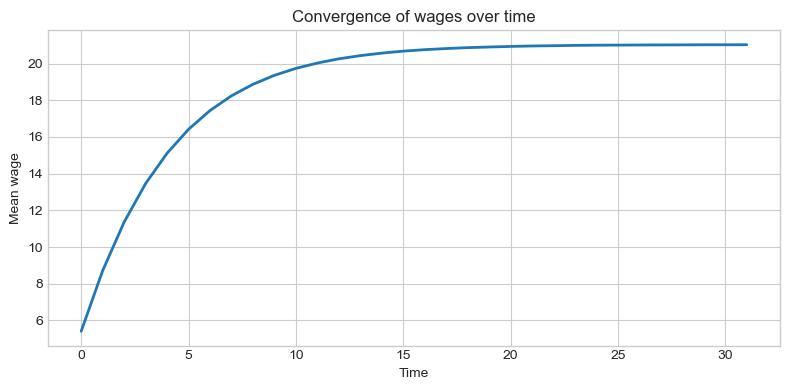

C:\Users\per.eco\AppData\Local\Temp\ipykernel_8628\1720703960.py:18: RuntimeWarning: Mean of empty slice
  plt.plot(np.nanmean(model.sol.l_h, axis=0), linewidth=2)


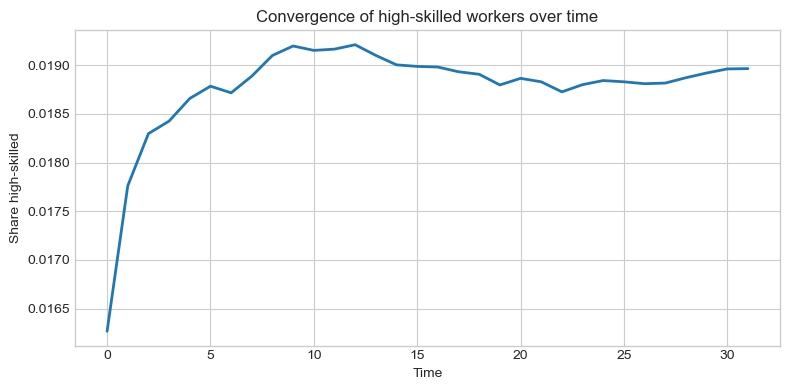

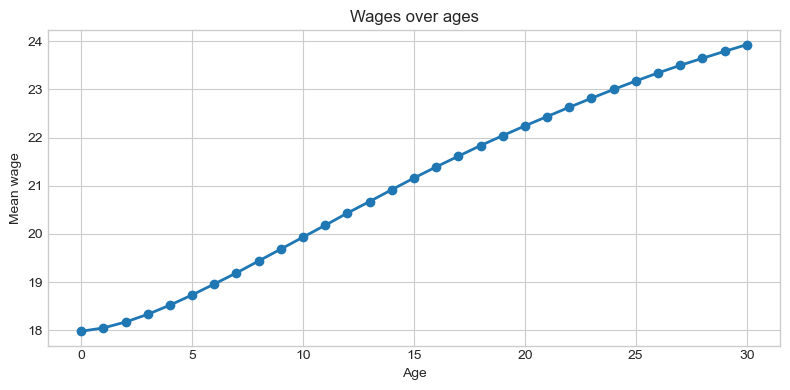

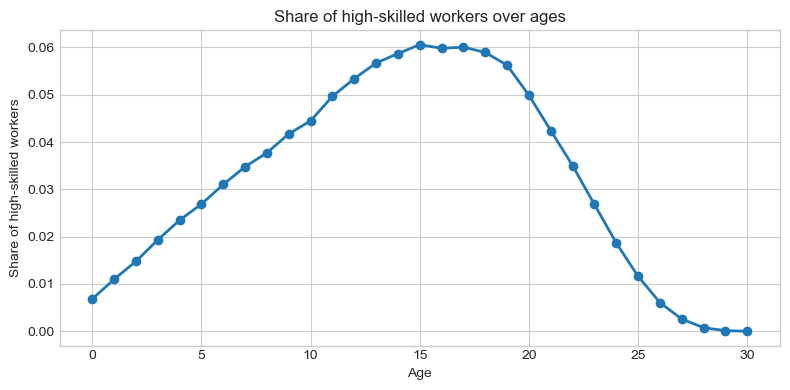

In [ ]:
t = model.sol.age[0,:].shape[0] - np.count_nonzero(model.sol.age[0,:]) - 1

plt.style.use("seaborn-v0_8-whitegrid")

age_groups = range(model.par.n)

# 1. Convergence of wages over time
plt.figure(figsize=(8, 4))
plt.plot(np.nanmean(model.sol.wage[:, :], axis=0), linewidth=2)
plt.title("Convergence of wages over time")
plt.xlabel("Time")
plt.ylabel("Mean wage")
plt.tight_layout() ,
plt.show()

# 2. Convergence of high-skilled workers over time
plt.figure(figsize=(8, 4))
plt.plot(np.nanmean(model.sol.l_h, axis=0), linewidth=2)
plt.title("Convergence of high-skilled workers over time")
plt.xlabel("Time")
plt.ylabel("Share high-skilled")
plt.tight_layout()
plt.show()

# 3. Wages over ages
means = [
    np.nanmean(model.sol.wage[:, t][model.sol.age[:, t] == i])
    for i in age_groups
]

plt.figure(figsize=(8, 4))
plt.plot(list(age_groups), means, marker="o", linewidth=2)
plt.title("Wages over ages")
plt.xlabel("Age")
plt.ylabel("Mean wage")
plt.tight_layout()
plt.show()

# 4. Share of high-skilled workers over ages, weighted by cohort mass
l_h_mask = (model.sol.l_h[:, t] == 1)

count = [
    np.nansum(model.sol.mass[l_h_mask & (model.sol.age[:, t] == i), t])
    for i in age_groups
]

count = np.array(count) / np.sum(count)

# count = [
#     np.nanmean(model.sol.l_h[:, t][model.sol.age[:, t] == i])
#     for i in age_groups
# ]

plt.figure(figsize=(8, 4))
plt.plot(list(age_groups), count, marker="o", linewidth=2)
plt.title("Share of high-skilled workers over ages")
plt.xlabel("Age")
plt.ylabel("Share of high-skilled workers")
plt.tight_layout()
plt.show()